In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**This Python files is for illustrating the difference between custom image augmentation and imageDataGenerator augmentation**

## Install dependencies

**Import libraries**

In [ ]:
import os
os.environ['TF_KERAS'] = '1'
import tensorflow as tf
import segmentation_models as sm
import glob
from tensorflow.keras.layers import *
from keras.applications.vgg16 import VGG16
from keras.utils.vis_utils import plot_model
import cv2
import os
from keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import keras 
from tensorflow.keras.utils import normalize
from keras.metrics import MeanIoU
import numpy as np
from skimage.transform import AffineTransform, warp
from keras.models import load_model
import torchvision.models as models
from skimage import io, img_as_ubyte
from tensorflow.keras.models import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.layers import *
import random
from random import randint,choice
from scipy.ndimage import rotate
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from tensorflow.python.keras import backend as K
from sklearn.preprocessing import LabelEncoder
from natsort import natsorted
from tensorflow.keras.models import Sequential,  Model
from keras import Sequential, layers
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,BatchNormalization,Add,GlobalAveragePooling2D,UpSampling2D

**Data Pre-processing using custom data generators**

horizontal flip


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:64: UserWarning: /content/drive/MyDrive/augmented_masks/augmented_mask_0.png is a low contrast image


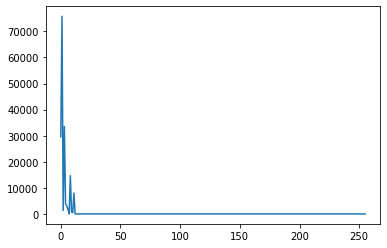

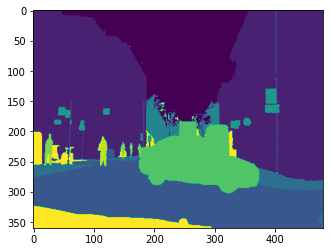

In [ ]:
def rotation(image, seed):
    random.seed(seed)
    angle= random.randint(-180,180)
    r_img = rotate(image, angle, mode='reflect', reshape=False, order=0)
    return r_img

def h_flip(image, seed):
    hflipped_img= np.fliplr(image)
    return  hflipped_img

def v_flip(image, seed):
    vflipped_img= np.flipud(image)
    return vflipped_img

def v_transl(image, seed):
    random.seed(seed)
    n_pixels = random.randint(-164,164)
    vtranslated_img = np.roll(image, n_pixels, axis=0)
    return vtranslated_img

def h_transl(image, seed):
    random.seed(seed)
    n_pixels = random.randint(-64,64)
    htranslated_img = np.roll(image, n_pixels, axis=1)
    return htranslated_img
seed_for_random = 42
transformations = {'rotate': rotation,
                    'horizontal flip': h_flip, 
                    'vertical flip': v_flip,
                   'vertical shift': v_transl,
                   'horizontal shift': h_transl
                 }                #use dictionary to store names of functions 

#images_path="/content/drive/MyDrive/dataset1 - Copy/images_prepped_train" #path to original images
masks_path = "/content/drive/MyDrive/Assignment3/trainMask/0001TP_008190.png"
#img_augmented_path="/content/drive/MyDrive/aug_imgs" # path to store aumented images
msk_augmented_path="/content/drive/MyDrive/augmented_masks" # path to store aumented images
#images=[] # to store paths of images from folder
masks=[]

#for im in os.listdir(images_path):  # read image name from folder and append its path into "images" array     
    #images.append(os.path.join(images_path,im))

#for msk in os.listdir(masks_path):  # read image name from folder and append its path into "images" array     
    #masks.append(os.path.join(masks_path,msk))

i=0   # variable to iterate till images_to_generate

while i<1: 
    #image = images[i]
    #mask = masks[i]
    #original_image = io.imread(image)
    original_mask = io.imread(masks_path)
    transformed_image = None
    transformed_mask = None
    key = np.random.choice(list(transformations)) #randomly choosing method to call
    print(key)
    seed = random.randint(1,100)  #Generate seed to supply transformation functions. 
    #transformed_image = transformations[key](original_image, seed)
    transformed_mask = transformations[key](original_mask, seed)
    #new_image_path= "%s/augmented_image_%s.png" %(img_augmented_path, i)
    new_mask_path = "%s/augmented_mask_%s.png" %(msk_augmented_path, i)   #Do not save as JPG
    #io.imsave(new_image_path, transformed_image)
    io.imsave(new_mask_path, transformed_mask)
    img = cv2.imread(new_mask_path,0)
    aug = cv2.calcHist([img],[0],None,[256],[0,256])
    plt.plot(aug)
    fig = plt.figure()
    ax1 = fig.add_subplot(1,1,1)
    ax1.imshow(img)
    plt.show()
    i =i+1



In [ ]:
datagen = ImageDataGenerator(
        rotation_range=45,     #Random rotation between 0 and 45
        width_shift_range=0.2,   #% shift
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='reflect')
images=[] # to store paths of images from folder
masks=[]
images_path="/content/drive/MyDrive/dataset1/images_prepped_train/" #path to original images
masks_path = "/content/drive/MyDrive/dataset1/annotations_prepped_test/"
for im in os.listdir(images_path):  # read image name from folder and append its path into "images" array     
    images.append(os.path.join(images_path,im))

for msk in os.listdir(masks_path):  # read image name from folder and append its path into "images" array     
    masks.append(os.path.join(masks_path,msk))

i=0   # variable to iterate till images_to_generate

while i<3: 
    image = images[i]
    mask = masks[i]
    print(i)      
    original_image = io.imread(image)
    original_mask = io.imread(mask)
    original_image = original_image.reshape(1,360,480,3)
    original_mask = original_mask.reshape(1,360,480,1)
    k= 0    
    for batch in datagen.flow(original_image, batch_size=16,  
                save_to_dir='/content/drive/MyDrive/augmented_Images/', 
                save_prefix='aug_img' + str(i), 
                save_format='png',
                seed=20):
            k += 1
            if k > 5:
              break  # otherwise the generator would loop indefinitely 

        #Generate Images
    j = 0
    for batch in datagen.flow(original_mask, batch_size=16,  
                                  save_to_dir='/content/drive/MyDrive/augmented_masks/', 
                                  save_prefix='aug_mask' + str(i), 
                                  save_format='png',
                                  seed=20):
            j += 1
            if j > 5:
                break 
    i = i+1                  

0
1
2


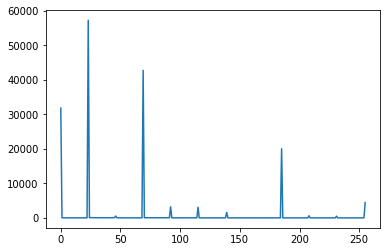

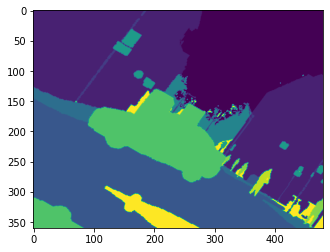

In [ ]:
img = cv2.imread("/content/drive/MyDrive/augmented_masks/aug_mask0_0_2975.png",0)
aug = cv2.calcHist([img],[0],None,[256],[0,256])
plt.plot(aug)
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.imshow(img)
plt.show()

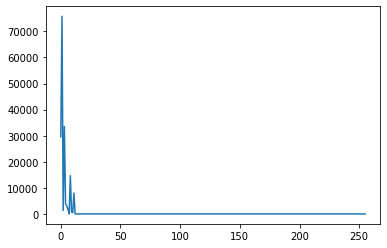

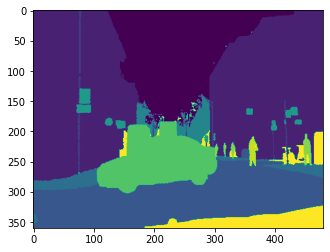

In [ ]:
org = cv2.calcHist([original_mask],[0],None,[256],[0,256])
plt.plot(org)
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.imshow(original_mask)
plt.show()